In [7]:
#results data
models = ["bert-large", "bert-large-pos", "bert-base", "bert-base-pos", "bert-base-deprel"]
f1_re_tacred = {
    "F1(1)": [89.77, 89.96, 87.93, 88.12, 88.09],
    "F1(2)": [89.67, 89.46, 88.29, 87.75, 87.92],
    "F1(3)": [89.51, 89.41, 88.08, 88.10, 87.80],
    "Mean F1": [89.65, 89.61, 88.08, 87.99, 87.94]
}
f1_tacred = {
    "F1(1)": [72.19, 73.09, 70.93, 70.36, 70.14],
    "F1(2)": [73.21, 72.65, 71.31, 71.02, 71.19],
    "F1(3)": [72.34, 72.01, 70.92, 71.38, 70.40],
    "Mean F1": [72.58, 72.58, 71.05, 70.92, 70.57]
}
mean_f1_re_tacred = [89.65, 89.61, 88.08, 87.99, 87.94]
mean_f1_tacred = [72.58, 72.58, 71.05, 70.92, 70.57]


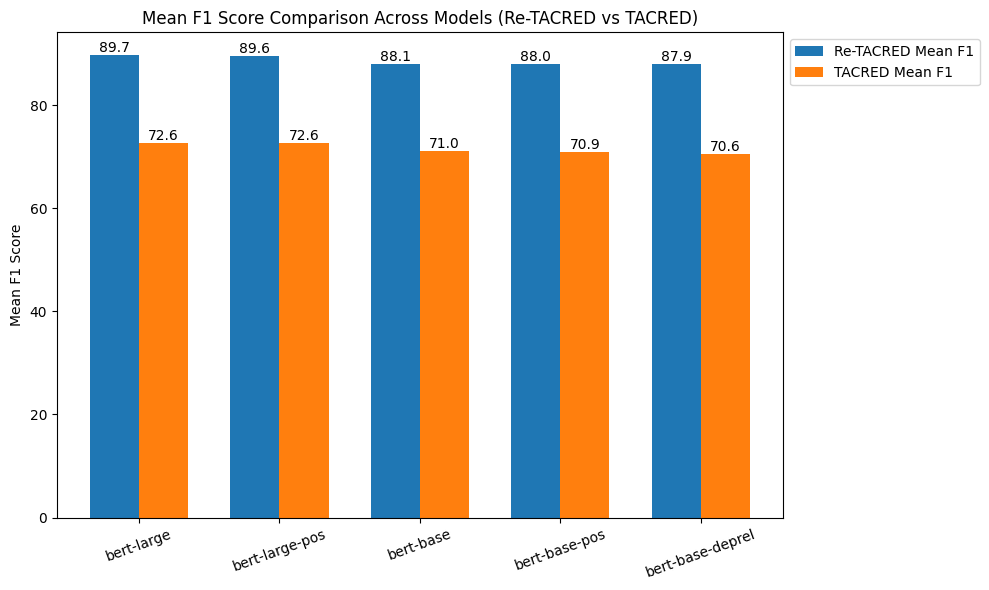

In [9]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

# x axis position
x = np.arange(len(models))
width = 0.35

# retacred bars
rects1 = ax.bar(x - width/2, f1_re_tacred["Mean F1"], width, label="Re-TACRED Mean F1")

#tacred bars
rects2 = ax.bar(x + width/2, f1_tacred["Mean F1"], width, label="TACRED Mean F1")

#label, titles
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20)
ax.set_ylabel("Mean F1 Score")
ax.set_title("Mean F1 Score Comparison Across Models (Re-TACRED vs TACRED)")
ax.legend()

#move legend so it doesn't overlap bars
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

#put values on bars
for rect in rects1 + rects2:
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, height, f"{height:.1f}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


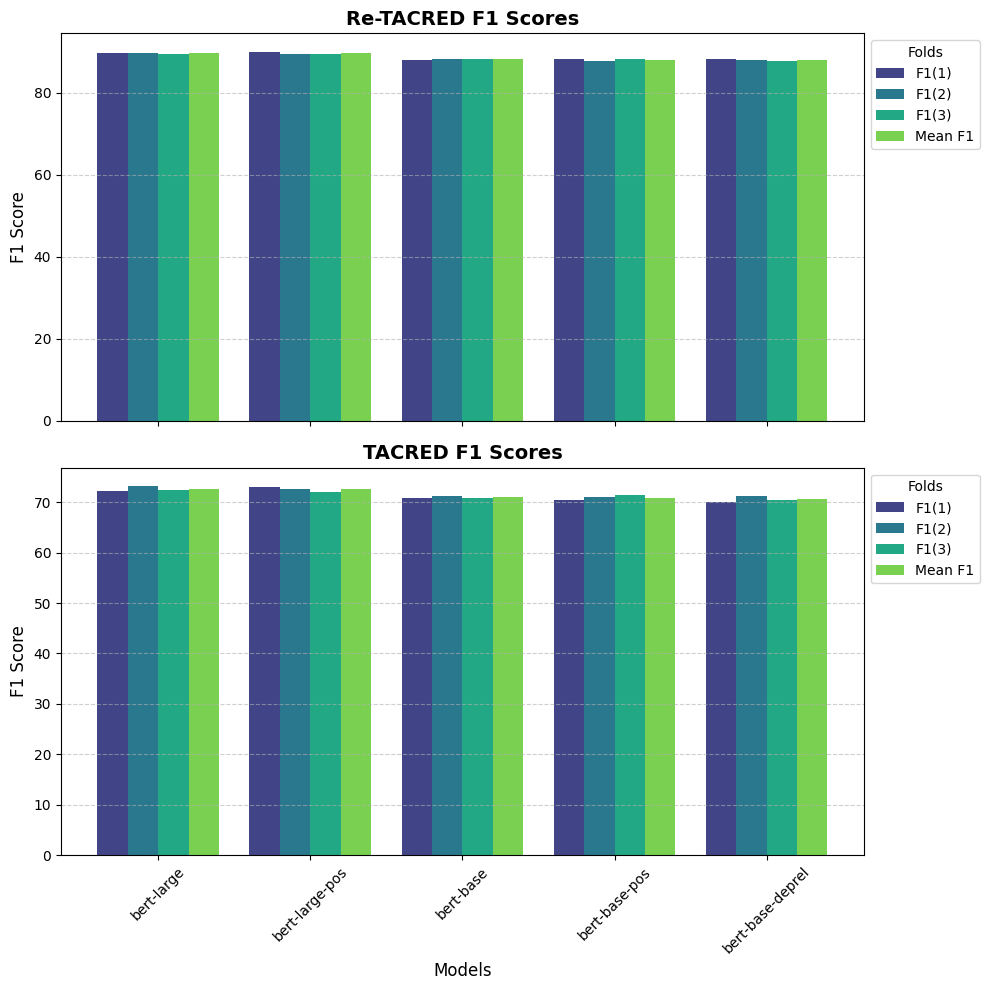

In [ ]:
import matplotlib.cm as cm


num_folds = len(f1_re_tacred)
#I'm not seeing colors I like - change colors here
colors = cm.viridis(np.linspace(0.2, 0.8, num_folds))

# figs one on top of the other
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 10), sharex=True)

bar_width = 0.2
x = np.arange(len(models))  # x positions for models
folds = ["F1(1)", "F1(2)", "F1(3)", "Mean F1"]

# plot retacred
for i, (fold, color) in enumerate(zip(folds, colors)):
    ax1.bar(x + (i - 1.5) * bar_width, f1_re_tacred[fold], bar_width, color=color, label=fold)

ax1.set_title("Re-TACRED F1 Scores", fontsize=14, fontweight='bold')
ax1.set_ylabel("F1 Score", fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=45)
ax1.grid(axis='y', linestyle='--', alpha=0.6) 

#make legend outside plot
ax1.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Folds")

#plot tacred
for i, (fold, color) in enumerate(zip(folds, colors)):
    ax2.bar(x + (i - 1.5) * bar_width, f1_tacred[fold], bar_width, color=color, label=fold)

ax2.set_title("TACRED F1 Scores", fontsize=14, fontweight='bold')
ax2.set_xlabel("Models", fontsize=12)
ax2.set_ylabel("F1 Score", fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=45)
ax2.grid(axis='y', linestyle='--', alpha=0.6) 

#legend not overlapping bars
ax2.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Folds")

plt.tight_layout()
plt.show()